<a href="https://colab.research.google.com/github/fahadabdullah-lab/smap-dispatch-gee-south-texas/blob/main/notebooks/03_dispatch_physics_daily_ipynb.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **03_dispatch_physics_daily.ipynb**

### **Cell 00 — Install + imports**

In [ ]:
!pip -q install earthengine-api geemap

import ee
import geemap

### **Cell 0 — Authenticate + initialize**

In [ ]:
ee.Authenticate()
ee.Initialize(project='ee-fafahadabdullah')
print("✅ Earth Engine initialized.")

### **Cell 1 - Inputs check + bring forward required variables**

This cell assumes you already have these variables in the Notebook 03 runtime:

aoi, start_date, end_date

smap_composite

ndvi

lst_composite_qc

Since Notebook 03 is a new notebook, we’ll rebuild the composites quickly the same way as Notebook 02 (stable + consistent), but only minimal, so Notebook 03 is self-contained.

In [ ]:
import ee
import geemap

# 1) Initialize Earth Engine
try:
    ee.Initialize(project="ee-fafahadabdullah")
    print("✅ Earth Engine initialized (project=ee-fafahadabdullah)")
except Exception:
    print("🔐 Authenticating Earth Engine...")
    ee.Authenticate()
    ee.Initialize(project="ee-fafahadabdullah")
    print("✅ Earth Engine initialized (project=ee-fafahadabdullah)")

# 2) REQUIRED: set these to match Notebook 02
TEST_DATE = "2021-08-15"
COMPOSITE_DAYS = 10
HALF_WINDOW = COMPOSITE_DAYS // 2

center = ee.Date(TEST_DATE)
start_date = center.advance(-HALF_WINDOW, "day")
end_date   = center.advance(HALF_WINDOW + 1, "day")  # end exclusive

print("📅 Window:", start_date.format("YYYY-MM-dd").getInfo(), "to", end_date.format("YYYY-MM-dd").getInfo(), "(end exclusive)")

# 3) REQUIRED: draw/load AOI (same method as Notebook 02)
Map = geemap.Map(center=[26.1, -97.3], zoom=9)
Map.add_basemap("HYBRID")
Map.add_draw_control()
print("🟨 Draw the SAME AOI polygon as Notebook 02, then run the next cell to convert to 'aoi'.")
Map

### **Cell 2 - Convert drawn polygon → AOI**

In [ ]:
# ------------------------------------------------
# Convert drawn polygon to Earth Engine geometry
# ------------------------------------------------

drawn_features = Map.draw_control.data

if drawn_features is None or len(drawn_features) == 0:
    raise ValueError("❌ No polygon detected. Please draw an AOI first.")

# Convert to Earth Engine FeatureCollection
drawn_fc = ee.FeatureCollection(drawn_features)

# Extract geometry
aoi = ee.Feature(drawn_fc.first()).geometry()

print("✅ AOI successfully converted to Earth Engine geometry")

# ------------------------------------------------
# Print AOI area
# ------------------------------------------------

area_km2 = aoi.area().divide(1e6)

print("AOI area (km²):", area_km2.getInfo())

# ------------------------------------------------
# Visualize AOI
# ------------------------------------------------

Map.addLayer(aoi, {"color": "yellow"}, "AOI Geometry")

Map

## **Cell 3 - SMAP composite (coarse constraint)**

In [ ]:
# ------------------------------------------------
# SMAP Soil Moisture composite
# ------------------------------------------------

SMAP_COLLECTION = "NASA/SMAP/SPL3SMP_E/005"

smap_ic = (
    ee.ImageCollection(SMAP_COLLECTION)
    .filterDate(start_date, end_date)
    .select("soil_moisture_am")
)

print("SMAP images:", smap_ic.size().getInfo())

smap = smap_ic.mean().clip(aoi)

print("✅ SMAP composite created")

# Visualization
smap_vis = {
    "min": 0.05,
    "max": 0.45,
    "palette": ["red","yellow","green"]
}

Map.addLayer(smap, smap_vis, "SMAP Soil Moisture")

Map

### **Cell 4 - MODIS LST composite (QC filtered)**

In [ ]:
# ------------------------------------------------
# MODIS LST composite (QC filtered)
# ------------------------------------------------

MODIS_LST = "MODIS/061/MOD11A1"

lst_ic = (
    ee.ImageCollection(MODIS_LST)
    .filterDate(start_date, end_date)
    .select(["LST_Day_1km","QC_Day"])
)

print("MODIS LST images:", lst_ic.size().getInfo())

def scale_qc_lst(img):

    qc = img.select("QC_Day")

    mandatory = qc.bitwiseAnd(3)
    dataq = qc.rightShift(2).bitwiseAnd(3)

    good = mandatory.eq(0).And(dataq.eq(0))

    lst = img.select("LST_Day_1km").multiply(0.02).subtract(273.15)

    return lst.updateMask(good)

lst = lst_ic.map(scale_qc_lst).mean().clip(aoi)

print("✅ LST composite created")

Map.addLayer(lst, {"min":20,"max":45,"palette":["blue","cyan","yellow","red"]}, "LST")

Map

### **Cell 5 - NDVI composite**

In [ ]:
# ------------------------------------------------
# MODIS NDVI composite
# ------------------------------------------------

MODIS_REFL = "MODIS/061/MOD09GA"

refl_ic = (
    ee.ImageCollection(MODIS_REFL)
    .filterDate(start_date, end_date)
    .select(["sur_refl_b01","sur_refl_b02"])
)

print("MODIS reflectance images:", refl_ic.size().getInfo())

def scale_refl(img):

    red = img.select("sur_refl_b01").multiply(0.0001)
    nir = img.select("sur_refl_b02").multiply(0.0001)

    return ee.Image.cat([
        red.rename("RED"),
        nir.rename("NIR")
    ])

refl = refl_ic.map(scale_refl).mean().clip(aoi)

ndvi = refl.normalizedDifference(["NIR","RED"]).rename("NDVI")

print("✅ NDVI computed")

Map.addLayer(ndvi, {"min":0,"max":0.8,"palette":["brown","yellow","green"]}, "NDVI")

Map

# **DISPATCH core**

### **Cell 6 - Compute Fractional Vegetation Cover (FVC)**

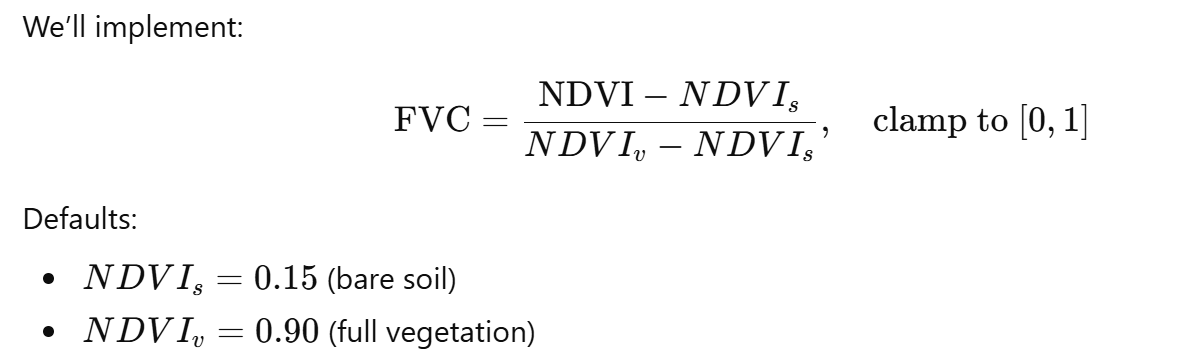

In [ ]:
# ------------------------------------------------
# Fractional Vegetation Cover (FVC)
# ------------------------------------------------

NDVI_S = 0.15
NDVI_V = 0.90

fvc = (ndvi.subtract(NDVI_S)
       .divide(NDVI_V - NDVI_S)
       .clamp(0, 1)
       .rename("FVC"))

print("✅ FVC computed")

Map.addLayer(fvc, {"min": 0, "max": 1, "palette": ["brown", "yellow", "green"]}, "FVC")
Map

### **Cell 7 - Build the MODIS stack + safe sampling for triangle edges**
We will sample NDVI + LST to estimate Tmin/Tmax.

In [ ]:
# ------------------------------------------------
# Build stack and sample pixels for triangle fitting
# ------------------------------------------------

modis_stack = ee.Image.cat([
    ndvi.rename("NDVI"),
    lst.rename("LST")
]).clip(aoi)

samples = modis_stack.sample(
    region=aoi,
    scale=1000,
    numPixels=20000,
    seed=42,
    geometries=False
)

print("Sampling NDVI+LST pixels...")

sample_df = geemap.ee_to_df(samples)

print("✅ Sample size:", len(sample_df))
sample_df.head()

### **Cell 8 - Extract Tmin/Tmax by NDVI bins (percentile envelopes)**

This is the robust way to build the triangle edges:

bin NDVI (e.g., 0.02)

per bin compute:

Tmin_bin = 10th percentile

Tmax_bin = 90th percentile

fit lines to those bin points

In [ ]:
import numpy as np
import pandas as pd

# Clean and keep realistic ranges
df = sample_df.copy()
df = df.replace([np.inf, -np.inf], np.nan).dropna()

# Optional sanity filters
df = df[(df["NDVI"] >= -0.2) & (df["NDVI"] <= 1.0)]
df = df[(df["LST"] >= -10) & (df["LST"] <= 60)]

print("✅ Clean sample size:", len(df))

# NDVI binning
BIN = 0.02
df["ndvi_bin"] = (np.floor(df["NDVI"] / BIN) * BIN).round(2)

# Percentile envelopes
edges = (df.groupby("ndvi_bin")["LST"]
         .agg(Tmin=lambda x: np.percentile(x, 10),
              Tmax=lambda x: np.percentile(x, 90),
              n="count")
         .reset_index()
         .rename(columns={"ndvi_bin": "NDVI_bin"}))

# Keep bins with enough points for stable percentiles
edges = edges[edges["n"] >= 5].copy()

print("✅ Bins retained:", len(edges))
edges.head()

### **Cell 9 - Plot the triangle + Tmin/Tmax envelopes**

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.scatter(df["NDVI"], df["LST"], s=15, alpha=0.5, label="Samples")

plt.plot(edges["NDVI_bin"], edges["Tmin"], linewidth=2, label="Tmin (10th pct)")
plt.plot(edges["NDVI_bin"], edges["Tmax"], linewidth=2, label="Tmax (90th pct)")

plt.xlabel("NDVI")
plt.ylabel("LST (°C)")
plt.title("DISPATCH Triangle with Tmin/Tmax Envelopes")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

### **Cell 10 - Estimate vegetation temperature 𝑇𝑣**

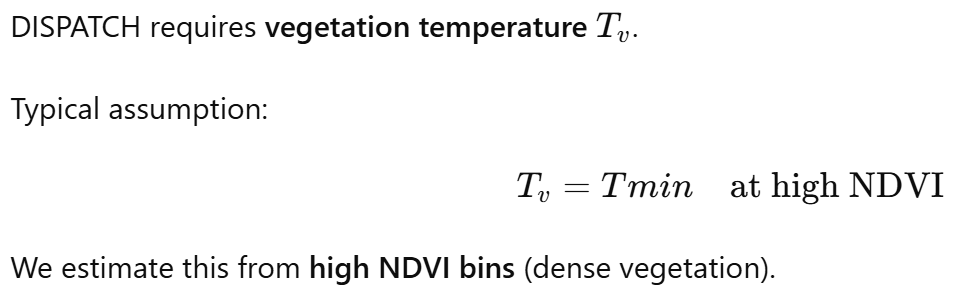

In [ ]:
# ------------------------------------------------
# Estimate vegetation temperature Tv
# ------------------------------------------------

# Select high NDVI bins (dense vegetation)
high_ndvi = edges[edges["NDVI_bin"] > 0.4]

Tv = high_ndvi["Tmin"].mean()

print("Estimated vegetation temperature Tv (°C):", round(Tv,2))

### **Cell 11 - Compute Soil Temperature Proxy 𝑇𝑠**

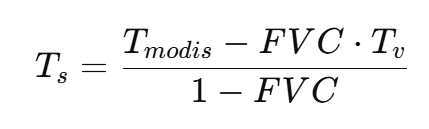

In [ ]:
# ------------------------------------------------
# Soil temperature proxy Ts
# ------------------------------------------------

Ts = (lst.subtract(fvc.multiply(Tv))
      .divide(ee.Image(1).subtract(fvc).max(0.001))
      .rename("Ts"))

print("✅ Soil temperature proxy computed")

Map.addLayer(Ts, {"min":25,"max":45,"palette":["blue","yellow","red"]}, "Soil Temperature Ts")
Map

### **Cell 12 - Convert Tmin/Tmax edges to functions**

In [ ]:
# ------------------------------------------------
# Fit linear models for Tmin(NDVI) and Tmax(NDVI)
# ------------------------------------------------

from sklearn.linear_model import LinearRegression

X = edges["NDVI_bin"].values.reshape(-1,1)

model_min = LinearRegression().fit(X, edges["Tmin"])
model_max = LinearRegression().fit(X, edges["Tmax"])

a_min, b_min = model_min.coef_[0], model_min.intercept_
a_max, b_max = model_max.coef_[0], model_max.intercept_

print("Tmin model: LST =", round(a_min,2),"* NDVI +",round(b_min,2))
print("Tmax model: LST =", round(a_max,2),"* NDVI +",round(b_max,2))

### **Cell 13 - Compute Tmin and Tmax maps**

In [ ]:
# ------------------------------------------------
# Compute Tmin and Tmax images
# ------------------------------------------------

Tmin_img = ndvi.multiply(a_min).add(b_min).rename("Tmin")
Tmax_img = ndvi.multiply(a_max).add(b_max).rename("Tmax")

Map.addLayer(Tmin_img, {"min":25,"max":40}, "Tmin")
Map.addLayer(Tmax_img, {"min":30,"max":45}, "Tmax")

Map

### **Cell 14 - Compute Soil Evaporative Efficiency (SEE)**

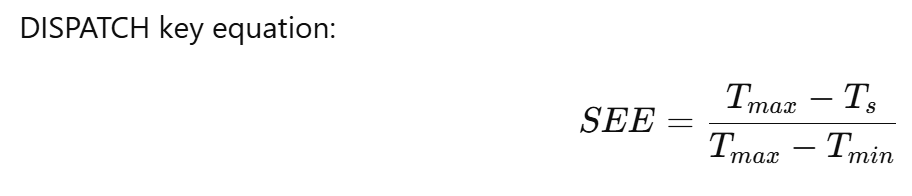

In [ ]:
# ------------------------------------------------
# Soil Evaporative Efficiency (SEE)
# ------------------------------------------------

SEE = (Tmax_img.subtract(Ts)
       .divide(Tmax_img.subtract(Tmin_img))
       .clamp(0,1)
       .rename("SEE"))

print("✅ SEE computed")

Map.addLayer(SEE, {"min":0,"max":1,"palette":["red","yellow","green"]}, "SEE")
Map

In [ ]:
# ------------------------------------------------
# Add legend for SEE map
# ------------------------------------------------

legend_dict = {
    "Very Dry (SEE ≈ 0)": "#ff0000",
    "Moderately Dry": "#ffa500",
    "Moderate": "#ffff00",
    "Moist": "#7fff00",
    "Very Wet (SEE ≈ 1)": "#00ff00"
}

Map.add_legend(
    title="Soil Evaporative Efficiency (SEE)",
    legend_dict=legend_dict
)

Map

### **Cell 15 - Compute SEE mean at SMAP scale**

In [ ]:
# ------------------------------------------------
# Cell 15 (SAFE): Compute SEE mean at SMAP scale using 2-stage aggregation
# ------------------------------------------------

smap_proj = smap.projection()
print("✅ SMAP scale (m):", smap_proj.nominalScale().getInfo())

modis_proj = lst.projection()
modis_crs  = modis_proj.crs()

# Force default projection on SEE at 1 km
SEE_1km = SEE.setDefaultProjection(modis_crs, None, 1000)

# Stage 1: 1 km -> 2 km (factor 4)
SEE_2km = (SEE_1km
           .reduceResolution(reducer=ee.Reducer.mean(), maxPixels=1024)
           .reproject(crs=modis_crs, scale=2000)
           .rename("SEE_2km"))

# Stage 2: 2 km -> SMAP grid (factor ~ (11km/2km)^2 ~ 30, safe)
SEE_mean_smap = (SEE_2km
                 .reduceResolution(reducer=ee.Reducer.mean(), maxPixels=1024)
                 .reproject(smap_proj)
                 .rename("SEE_mean_smap"))

print("✅ SEE_mean_smap created (2-stage safe)")

Map.addLayer(SEE_mean_smap.clip(aoi),
             {"min":0, "max":1, "palette":["red","yellow","green"]},
             "SEE mean (SMAP scale)")
Map

### **Cell 16 - Create SM_1km (downscaled soil moisture)**

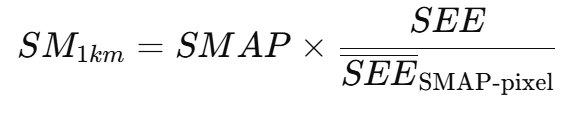

In [ ]:
# ------------------------------------------------
# Cell 16: Downscaled soil moisture at 1 km (ratio SHMS) - using safe SEE_mean_smap
# ------------------------------------------------

eps = 1e-6
modis_proj = lst.projection()
modis_crs  = modis_proj.crs()

# Ensure SEE is truly 1 km-projected
SEE_1km = SEE.setDefaultProjection(modis_crs, None, 1000)

# Resample SMAP to MODIS 1 km grid
smap_1km = (smap
            .resample("bilinear")
            .reproject(crs=modis_crs, scale=1000)
            .rename("SMAP_1km"))

# Bring coarse SEE mean back to 1 km for ratio
SEE_mean_1km = (SEE_mean_smap.max(eps)
                .resample("bilinear")
                .reproject(crs=modis_crs, scale=1000)
                .rename("SEE_mean_1km"))

ratio = (SEE_1km.divide(SEE_mean_1km)
         .clamp(0, 2)
         .rename("SEE_ratio"))

SM_1km = (smap_1km.multiply(ratio)
          .clamp(0, 0.6)
          .rename("SM_1km")
          .clip(aoi))

print("✅ SM_1km created")

Map.addLayer(SM_1km,
             {"min":0.05, "max":0.45, "palette":["red","yellow","green"]},
             "Downscaled Soil Moisture (1 km)")
Map

In [ ]:
legend_sm = {
    "Dry (~0.05)": "#ff0000",
    "Moderate": "#ffff00",
    "Wet (~0.45)": "#00ff00"
}
Map.add_legend(title="Downscaled Soil Moisture (m³/m³)", legend_dict=legend_sm)
Map